# Merging strategies

In [2]:
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import sklearn.metrics
from tqdm import tqdm
import numpy as np
import pickle
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import corc.our_datasets
import os
import time

path = cache_path = '../../cache/'

In [4]:
def plot_mask(transformed_points, mask, best_mask, ax, s_size, title="", fontsize=12):
    ax.scatter(
        transformed_points[mask, 0],
        transformed_points[mask, 1],
        c="black",
        s=s_size,
        label="Correctly Classified",
    )
    ax.scatter(
        transformed_points[~mask, 0],
        transformed_points[~mask, 1],
        c="#e41a1c", # red
        s=s_size,
        label="Misclassified",
    )
    ax.scatter(
        transformed_points[~best_mask, 0],
        transformed_points[~best_mask, 1],
        c="orange", # orange
        s=s_size,
        label="always Misclassified",
    )
    ax.annotate(title, xy=(0.5, .97), xycoords='axes fraction', ha='center', fontsize=fontsize)
    # ax.title.set_y(1.3)
    # ax.set_title(title, fontsize=fontsize)

In [ ]:
def create_plot_claude(X, transformed_points, y, tmm_model, seed=None, n_components=None, edges=False):
    """
    Create a visualization grid comparing different clustering methods.
    
    Parameters:
    -----------
    X : np.ndarray
        Original input data
    transformed_points : np.ndarray
        2D transformed points for visualization (e.g., from t-SNE)
    y : np.ndarray
        Ground truth labels
    tmm_model : object
        TMM model instance
    seed : int, optional
        Random seed for reproducibility
    n_components : int, optional
        Number of components used in the transformation
    
    Returns:
    --------
    matplotlib.figure.Figure
        The completed figure
    """
    
    def plot_single_cluster(ax, points, labels, centers=None, title=None,cmap='viridis', edges=False):
        """Helper function to plot a single cluster visualization."""
        ax.scatter(points[:, 0], points[:, 1], c=cmap[labels], s=SCATTER_SIZE)
        if centers is not None:
            ax.scatter(centers[:, 0], centers[:, 1], c="black", marker="x", s=MARKER_SIZE)
        if title:
            ax.set_title(title)
        ax.axis('off')

        if edges:
            # add lines between centers of the same cluster
            if centers is not None:
                center_colors = np.zeros(len(centers))
                for index in range(len(centers)):
                    # get color of the center
                    center_colors[index] = labels[np.where(np.logical_and(points[:,1] == centers[index,1],points[:,1] == centers[index,1]))[0][0]]
                
                for colorclass in np.unique(labels):
                    indices = np.where(center_colors == colorclass)
                    for i in range(len(indices[0])):
                        for j in range(i+1, len(indices[0])):
                            ax.plot([centers[indices[0][i], 0], centers[indices[0][j], 0]], [centers[indices[0][i], 1], centers[indices[0][j], 1]], c='black', alpha=0.5)

    def add_row_label(ax, label):
        """Helper function to add consistent row labels."""
        ax.text(-0.05, 0.5, label, transform=ax.transAxes,
                fontsize=6, rotation=90, va='center', ha='right')

    # Constants
    MARKER_SIZE = 14
    SCATTER_SIZE = 0.2
    N_ROWS, N_COLS = 2, 4
    fontsize = 12
    cmap = corc.visualization.get_color_scheme(len(np.unique(y)))
    # Setup figure
    fig, axs = plt.subplots(N_ROWS, N_COLS, figsize=(6.75, 3.75))
    for ax in axs.flat:
        ax.set_aspect('equal') 
    # plt.subplots_adjust(wspace=-0.2, hspace=0.1)  # Reduced spacing between subplots
    for ax in axs.flat:
        ax.axis('off')

    # # Add row labels
    # row_labels = {
    #     0: ["Ground Truth", "Dip-stats"],
    #     1: ["Nearest Neighbor", "MDP (ours)"]
    # }
    # for row in [0, 1]:
    #     add_row_label(axs[row, 0], row_labels[row][0])
    #     add_row_label(axs[row, 2], row_labels[row][1])

    # Get centers in transformed space
    centers = corc.visualization.snap_points_to_TSNE(
        tmm_model.mixture_model.centers, X, transformed_points
    )
    
    # 1. Ground Truth
    y_pred_raw = tmm_model.mixture_model.predict(X)
    y_best = corc.utils.best_possible_labels_from_overclustering(
        y, y_pred_raw
    )
    correct_mask = y == y_best
    plot_single_cluster(axs[0, 0], transformed_points, y,cmap=cmap)
    axs[0, 0].set_title("Oracle", fontsize=fontsize, pad=0)
    plot_mask(
        transformed_points,
        correct_mask,
        correct_mask,
        axs[1, 0],
        title=f"ARI: {adjusted_rand_score(y, y_best):.2f}",
        s_size=SCATTER_SIZE,
        fontsize=fontsize
    )

    # 2. Baseline (Nearest Neighbor)
    y_baseline = get_baseline_predictions(tmm_model, X, y)
    plot_single_cluster(axs[0, 1], transformed_points, y_baseline, centers,cmap=cmap, edges=edges)
    axs[0, 1].set_title(" Euclidean", fontsize=fontsize, pad=0)
    plot_mask(
        transformed_points,
        (y == y_baseline),
        correct_mask,
        axs[1, 1],
        title=f"ARI: {adjusted_rand_score(y, y_baseline):.2f}",
        s_size=SCATTER_SIZE,
        fontsize=fontsize
    )

    # 3. Dip-stats
    y_dip = get_dip_stat_predictions(tmm_model, X, y)
    plot_single_cluster(axs[0, 2], transformed_points, y_dip, centers,cmap=cmap, edges=edges)
    axs[0, 2].set_title(" Dip-stats", fontsize=fontsize, pad=0)
    plot_mask(
        transformed_points,
        (y == y_dip),
        correct_mask,
        axs[1, 2],
        title=f"ARI: {adjusted_rand_score(y, y_dip):.2f}",
        s_size=SCATTER_SIZE,
        fontsize=fontsize
    )

    # 4. Our method (MDP)
    y_pred = tmm_model.predict_with_target(X, len(np.unique(y)))
    y_pred = corc.visualization.reorder_colors(y_pred, y)
    plot_single_cluster(axs[0, 3], transformed_points, y_pred, centers,cmap=cmap, edges=edges)
    axs[0, 3].set_title(r"  NEB (ours)", fontsize=fontsize, pad=0)
    plot_mask(
        transformed_points,
        (y == y_pred),
        correct_mask,
        axs[1, 3],
        title=f"ARI: {adjusted_rand_score(y, y_pred):.2f}",
        s_size=SCATTER_SIZE,
        fontsize=fontsize
    )

    # A,B,C,D labels
    axs[0,0].annotate('A', xy=(0, 1), xycoords='axes fraction',
                xytext=(25, 0), textcoords='offset points',
                ha='right', va='bottom', size=fontsize+4, weight='bold')
    axs[0,1].annotate('B', xy=(0, 1), xycoords='axes fraction',
                xytext=(20, 0), textcoords='offset points',
                ha='right', va='bottom', size=fontsize+4, weight='bold')
    axs[0,2].annotate('C', xy=(0, 1), xycoords='axes fraction',
                xytext=(20, 0), textcoords='offset points',
                ha='right', va='bottom', size=fontsize+4, weight='bold')
    axs[0,3].annotate('D', xy=(0, 1), xycoords='axes fraction',
                xytext=(20, 0), textcoords='offset points',
                ha='right', va='bottom', size=fontsize+4, weight='bold')

    fig.tight_layout()
    plt.subplots_adjust(wspace=-0., hspace=0.)
    return fig

def get_baseline_predictions(tmm_model, X, y):
    """Get predictions using the baseline nearest neighbor method."""
    y_pred_full = tmm_model.mixture_model.predict(X)
    y_baseline = corc.utils.predict_by_joining_closest_clusters(
        centers=tmm_model.mixture_model.centers,
        y_pred=y_pred_full,
        num_classes=len(np.unique(y)),
        dip_stat=False,
        data=X
    )
    y_baseline = np.array(y_baseline, dtype=int)
    return corc.visualization.reorder_colors(y_baseline, y)

def get_dip_stat_predictions(tmm_model, X, y):
    """Get predictions using the dip-stats method."""
    y_pred = tmm_model.predict(X)
    y_dip = corc.utils.predict_by_joining_closest_clusters(
        centers=tmm_model.mixture_model.centers,
        y_pred=np.asarray(y_pred.tolist()),
        num_classes=len(np.unique(y)),
        dip_stat=True,
        data=X
    )
    return corc.visualization.reorder_colors(y_dip, y)

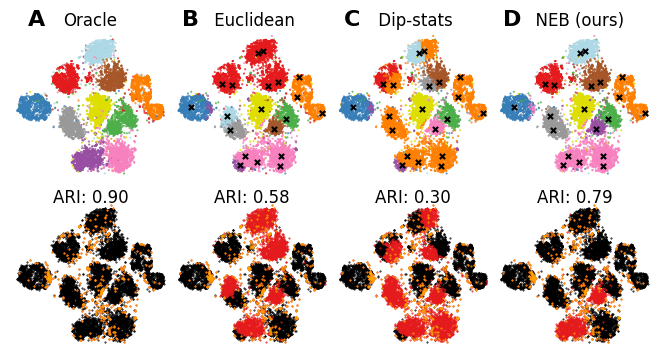

In [12]:
n_components = 25
dataset_name = 'mnist16'
seed = 42

X, y, transformed_points = corc.utils.load_dataset(
    dataset_name=dataset_name, cache_path=cache_path
)
tmms = corc.utils.load_tmms(dataset_name=dataset_name, cache_path=cache_path)
tmm_model = tmms[0]
        
# tmm_model = tmm_models[0]
figure = create_plot_claude(
    X=X, transformed_points=transformed_points, y=y, tmm_model=tmm_model, seed=seed, n_components=n_components
)
# plt.savefig(f"../../figures/join_strategies_{dataset_name}_{n_components}.png",
            # bbox_inches='tight', pad_inches=0, dpi=600)

# figure = create_plot_claude(
#     X=X, transformed_points=transformed_points, y=y, tmm_model=tmm_model, seed=seed, n_components=n_components, edges=True
# )
# plt.savefig(f"../../figures/join_strategies_{dataset_name}_{n_components}_edges.png",
#             bbox_inches='tight', pad_inches=0, dpi=600)

In [7]:
y_pred_full = tmm_model.mixture_model.predict(X)

In [72]:
y_baseline = corc.utils.predict_by_joining_closest_clusters(
        centers=tmm_model.mixture_model.centers,
        y_pred=y_pred_full,
        num_classes=10,
        dip_stat=True,
        recompute_distances=False,
        data=X
    )

IndexError: index 16 is out of bounds for axis 0 with size 13

In [10]:
np.unique(y_baseline)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
len(tmm_model.mixture_model.centers)

20

In [70]:
# dataset_name = "densired64"
dataset_name = "densired_soft_8"
# dataset_name = "mnist64"


X, y, transformed_points = corc.utils.load_dataset(
    dataset_name=dataset_name, cache_path=cache_path
)
tmms = corc.utils.load_tmms(dataset_name=dataset_name, cache_path=cache_path)
tmm_model = tmms[1]

In [71]:
start_time = time.time()
y_baseline = corc.utils.predict_by_joining_closest_clusters(
        centers=tmm_model.mixture_model.centers,
        y_pred=y_pred_full,
        num_classes=10,
        dip_stat=True,
        recompute_distances=False,
        data=X
    )
end_time = time.time()
print(f"dip stats takes {end_time-start_time:.2f}s")

IndexError: index 16 is out of bounds for axis 0 with size 13

In [66]:
start_time = time.time()
y_baseline = corc.utils.predict_by_joining_closest_clusters(
        centers=tmm_model.mixture_model.centers,
        y_pred=y_pred_full,
        num_classes=10,
        dip_stat=False,
        recompute_distances=False,
        data=X
    )
end_time = time.time()
print(f"euclidean takes {end_time-start_time:.2f}s")

euclidean takes 0.17s


In [69]:
for i in range(3):
    start_time = time.time()
    y_ours = corc.graph_metrics.tmm_gmm_neb.compute_neb_paths_batch(
        tmm_model.mixture_model.centers,
        tmm_model.mixture_model.covs,
        tmm_model.mixture_model.weights,
        tmm_model.mixture_model.df,
        iterations=100,
        num_NEB_points=10,
        batch_size=1000
    )
    end_time = time.time()
    print(f"NEB takes {end_time-start_time:.2f}s")

t-NEB: 100%|██████████| 1/1 [00:02<00:00,  2.09s/it]


NEB takes 2.63s


t-NEB: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


NEB takes 2.57s


t-NEB: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]


NEB takes 2.57s
